In [1]:
import argparse
import os
import numpy as np
import math
import sys

import torchvision.transforms as transforms
from torchvision.utils import save_image

from torch.utils.data import DataLoader, Dataset
from PIL import Image
from torchvision import datasets
from torch.autograd import Variable

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.autograd as autograd

In [2]:
import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

GPU available: True
GPU name: Tesla T4


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "gpu")

In [4]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rumiyyaalili","key":"ab121a81fb536037f0c3dd698d666bb2"}'}

In [5]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d ramanathansp20/inbreast-dataset

Dataset URL: https://www.kaggle.com/datasets/ramanathansp20/inbreast-dataset
License(s): unknown
100% 1.93G/1.93G [00:24<00:00, 114MB/s]
100% 1.93G/1.93G [00:24<00:00, 86.2MB/s]


In [7]:
!kaggle datasets download -d rumiyyaalili/rumiyya-256

Dataset URL: https://www.kaggle.com/datasets/rumiyyaalili/rumiyya-256
License(s): unknown
 29% 10.0M/34.9M [00:00<00:00, 28.6MB/s]
100% 34.9M/34.9M [00:00<00:00, 84.3MB/s]


In [8]:
!kaggle datasets download -d theoviel/rsna-breast-cancer-256-pngs

Dataset URL: https://www.kaggle.com/datasets/theoviel/rsna-breast-cancer-256-pngs
License(s): CC0-1.0
100% 998M/998M [00:13<00:00, 149MB/s]
100% 998M/998M [00:13<00:00, 78.2MB/s]


In [9]:
!unzip -qq rumiyya-256

In [10]:
!unzip -qq rsna-breast-cancer-256-pngs

In [11]:
!unzip -qq inbreast-dataset

In [12]:
import os

# Root directory to search for DCM files
search_dir = "/content"

# Find all DICOM files
dicom_files = []
for root, dirs, files in os.walk(search_dir):
    for file in files:
        if file.lower().endswith(".dcm"):
            dicom_files.append(os.path.join(root, file))

# Print folder where DICOM files are found
if dicom_files:
    print(f"Found {len(dicom_files)} DICOM files in: {os.path.dirname(dicom_files[0])}")
else:
    print("No DICOM files found. Check if the files are uploaded.")

Found 410 DICOM files in: /content/INbreast Release 1.0/AllDICOMs


In [14]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 35.5 MB/s eta 0:00:00


In [15]:
import os
import pydicom
import numpy as np
from PIL import Image

# Define input and output directories
dcm_folder = "/content/INbreast Release 1.0/AllDICOMs"  # Change this based on Step 1
output_folder = "/content/png_images"
os.makedirs(output_folder, exist_ok=True)

# Convert each DICOM file to PNG
for file in os.listdir(dcm_folder):
    if file.lower().endswith(".dcm"):
        dcm_path = os.path.join(dcm_folder, file)

        # Read DICOM file
        dicom_data = pydicom.dcmread(dcm_path)

        # Convert pixel data to uint8 format
        image = dicom_data.pixel_array.astype(np.float32)
        image = (image - image.min()) / (image.max() - image.min())  # Normalize
        image = (image * 255).astype(np.uint8)  # Scale to 0-255

        # Convert to PIL image and save as PNG
        img = Image.fromarray(image)
        png_filename = os.path.splitext(file)[0] + ".png"
        img.save(os.path.join(output_folder, png_filename))

        # Print confirmation for each file
        print(f"Converted: {file} → {png_filename}")

print(f"\nConversion complete. PNG images are saved in: {output_folder}")

Converted: 53582567_3e73f1c0670cfb0a_MG_R_CC_ANON.dcm → 53582567_3e73f1c0670cfb0a_MG_R_CC_ANON.png
Converted: 22614545_2dec4948fbe6336d_MG_R_ML_ANON.dcm → 22614545_2dec4948fbe6336d_MG_R_ML_ANON.png
Converted: 50997434_97ec8cadfca70d32_MG_L_ML_ANON.dcm → 50997434_97ec8cadfca70d32_MG_L_ML_ANON.png
Converted: 50994300_cc9e66c5b31baab8_MG_R_FB_ANON.dcm → 50994300_cc9e66c5b31baab8_MG_R_FB_ANON.png
Converted: 50998322_1e4b534393d18753_MG_R_ML_ANON.dcm → 50998322_1e4b534393d18753_MG_R_ML_ANON.png
Converted: 20588654_036aff49b8ac84f0_MG_R_ML_ANON.dcm → 20588654_036aff49b8ac84f0_MG_R_ML_ANON.png
Converted: 50998177_f34ee0ab6591b792_MG_L_ML_ANON.dcm → 50998177_f34ee0ab6591b792_MG_L_ML_ANON.png
Converted: 22579893_301f1776aebbf5d2_MG_R_ML_ANON.dcm → 22579893_301f1776aebbf5d2_MG_R_ML_ANON.png
Converted: 22670465_7e677f3d530e41ed_MG_L_CC_ANON.dcm → 22670465_7e677f3d530e41ed_MG_L_CC_ANON.png
Converted: 22614127_6bd24a0a42c19ce1_MG_R_ML_ANON.dcm → 22614127_6bd24a0a42c19ce1_MG_R_ML_ANON.png
Converted:

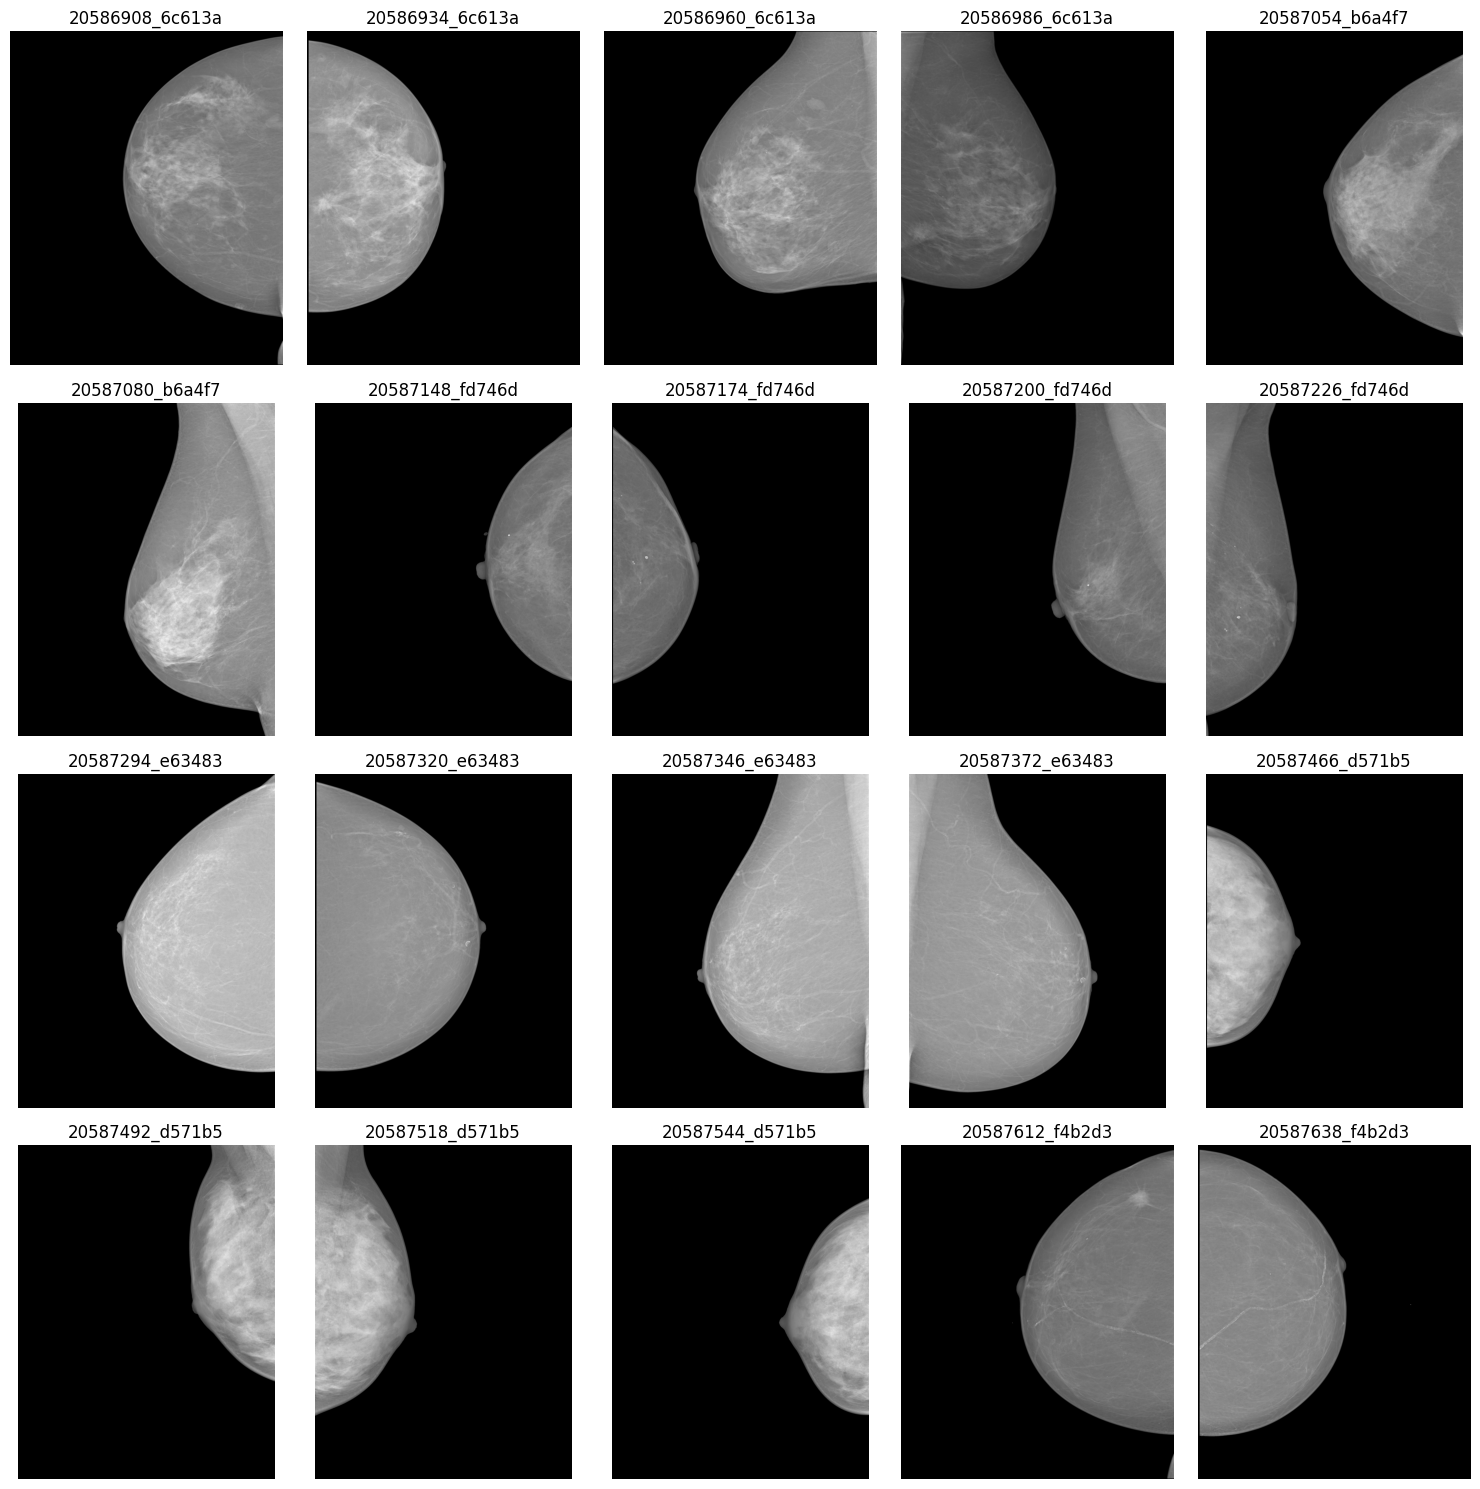

In [16]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Define the PNG output folder
output_folder = "/content/png_images"

# Get all PNG files in the folder
png_files = sorted([f for f in os.listdir(output_folder) if f.lower().endswith(".png")])

# Display the first 20 images
num_images = min(20, len(png_files))  # Ensure we don't exceed available images

plt.figure(figsize=(15, 15))
for i in range(num_images):
    img_path = os.path.join(output_folder, png_files[i])
    img = Image.open(img_path)

    # Plot image
    plt.subplot(4, 5, i + 1)  # 4 rows, 5 columns
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(png_files[i][:15])  # Show part of the filename

plt.tight_layout()
plt.show()

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
# FOR INBREAST
import os
import numpy as np
from PIL import Image
from google.colab import drive

# Step 1: Mount Google Drive
drive.mount('/content/drive')

# Paths
dataset_path = "/content/png_images"  # Input folder
aligned_dir = "/content/aligned_images"  # Temporary storage
drive_folder = "/content/drive/My Drive/InBreast_Aligned_Images"  # Permanent storage in Google Drive

os.makedirs(aligned_dir, exist_ok=True)  # Create aligned image directory
os.makedirs(drive_folder, exist_ok=True)  # Create Google Drive directory

# Function to classify and align images
def classify_breast(image):
    # Convert image to numpy array
    img_array = np.array(image)

    # Compute symmetry
    h, w = img_array.shape[:2]
    left_half = img_array[:, :w // 2]
    right_half = img_array[:, w // 2:]

    # Compute average pixel intensity for comparison
    left_mean = np.mean(left_half)
    right_mean = np.mean(right_half)

    # If left side is brighter, it's a left breast image
    return "LEFT" if left_mean > right_mean else "RIGHT"

# Process images
for img_file in os.listdir(dataset_path):
    if img_file.endswith(".png"):
        img_path = os.path.join(dataset_path, img_file)

        # Open image in grayscale
        image = Image.open(img_path).convert("L")

        # Resize to 256x256
        image = image.resize((256, 256))

        # Classify the image (LEFT or RIGHT)
        label = classify_breast(image)

        # Flip the image if it's a left breast
        if label == "LEFT":
            image = image.transpose(Image.FLIP_LEFT_RIGHT)  # Horizontal flip

        # Save the aligned image locally
        aligned_path = os.path.join(aligned_dir, img_file)
        image.save(aligned_path)

        # Save the aligned image to Google Drive
        drive_path = os.path.join(drive_folder, img_file)
        image.save(drive_path)

print(f"\nAligned images are saved permanently in: {drive_folder}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Aligned images are saved permanently in: /content/drive/My Drive/InBreast_Aligned_Images


In [19]:
import os
import numpy as np
from PIL import Image
from google.colab import drive

# Step 1: Mount Google Drive
drive.mount('/content/drive')

# Paths
dataset_path = "/content/"  # Input folder (where both JPG & PNG images are stored)
aligned_dir = "/content/aligned_images"  # Temporary storage
drive_folder = "/content/drive/My Drive/InBreast_Aligned_Images"  # Permanent storage in Google Drive (OneDrive folder)

# Ensure directories exist
os.makedirs(aligned_dir, exist_ok=True)
os.makedirs(drive_folder, exist_ok=True)

# Function to classify and align images
def classify_breast(image):
    img_array = np.array(image)

    # Compute symmetry
    h, w = img_array.shape[:2]
    left_half = img_array[:, :w // 2]
    right_half = img_array[:, w // 2:]

    # Compare pixel intensity
    left_mean = np.mean(left_half)
    right_mean = np.mean(right_half)

    return "LEFT" if left_mean > right_mean else "RIGHT"

# Process images
for img_file in os.listdir(dataset_path):
    if img_file.lower().endswith((".png", ".jpg", ".jpeg")):  # Accept both PNG & JPG
        img_path = os.path.join(dataset_path, img_file)

        # Open image in grayscale
        image = Image.open(img_path).convert("L")

        # Resize to 256x256
        image = image.resize((256, 256))

        # Classify (LEFT or RIGHT)
        label = classify_breast(image)

        # Flip the image if it's a left breast
        if label == "LEFT":
            image = image.transpose(Image.FLIP_LEFT_RIGHT)

        # Save aligned image locally
        aligned_path = os.path.join(aligned_dir, img_file)
        image.save(aligned_path)

        # Save to Google Drive (OneDrive folder)
        drive_path = os.path.join(drive_folder, img_file)
        image.save(drive_path)

print(f"\nAligned images are permanently stored in: {drive_folder}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Aligned images are permanently stored in: /content/drive/My Drive/InBreast_Aligned_Images


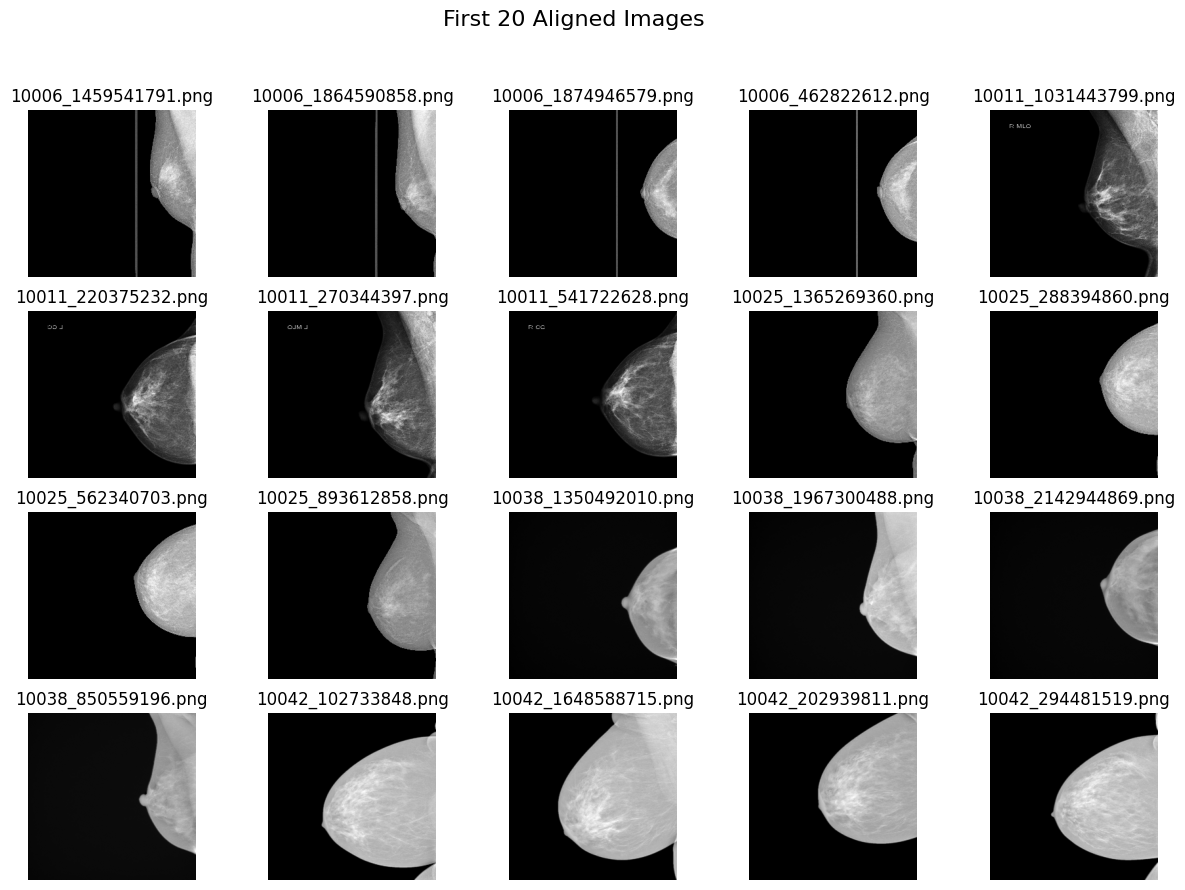

In [20]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Path to aligned images in Google Drive
drive_folder = "/content/drive/My Drive/InBreast_Aligned_Images"

# Get the list of image files
image_files = sorted(os.listdir(drive_folder))[:20]  # Get first 20 images

# Plot the images
plt.figure(figsize=(15, 10))

for i, img_file in enumerate(image_files):
    img_path = os.path.join(drive_folder, img_file)
    img = Image.open(img_path)

    plt.subplot(4, 5, i + 1)  # 4 rows, 5 columns
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(f"{img_file}")

plt.suptitle("First 20 Aligned Images", fontsize=16)
plt.show()

In [25]:
import os
import numpy as np
from PIL import Image
from google.colab import drive

# Step 1: Mount Google Drive
drive.mount('/content/drive')

# Paths
dataset_path = "/content/preprocessed_images"  # Input folder (where JPG images are stored)
aligned_dir = "/content/aligned_images"  # Temporary storage
drive_folder = "/content/drive/My Drive/InBreast_Aligned_Images"  # Permanent storage in Google Drive (OneDrive folder)

# Ensure directories exist
os.makedirs(aligned_dir, exist_ok=True)
os.makedirs(drive_folder, exist_ok=True)

# Function to classify and align images
def classify_breast(image):
    img_array = np.array(image)

    # Compute symmetry
    h, w = img_array.shape[:2]
    left_half = img_array[:, :w // 2]
    right_half = img_array[:, w // 2:]

    # Compare pixel intensity
    left_mean = np.mean(left_half)
    right_mean = np.mean(right_half)

    return "LEFT" if left_mean > right_mean else "RIGHT"

# Process only JPG images
for img_file in os.listdir(dataset_path):
    if img_file.lower().endswith((".jpg", ".jpeg")):  # Accept only JPG & JPEG
        img_path = os.path.join(dataset_path, img_file)

        # Open image in grayscale
        image = Image.open(img_path).convert("L")

        # Resize to 256x256
        image = image.resize((256, 256))

        # Classify (LEFT or RIGHT)
        label = classify_breast(image)

        # Flip the image if it's a left breast
        if label == "LEFT":
            image = image.transpose(Image.FLIP_LEFT_RIGHT)

        # Save aligned image locally
        aligned_path = os.path.join(aligned_dir, img_file)
        image.save(aligned_path)

        # Save to Google Drive (OneDrive folder)
        drive_path = os.path.join(drive_folder, img_file)
        image.save(drive_path)

print(f"\nAligned JPG images are permanently stored in: {drive_folder}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Aligned JPG images are permanently stored in: /content/drive/My Drive/InBreast_Aligned_Images


In [28]:
import os

# Path to the Google Drive folder
drive_folder = "/content/drive/My Drive/InBreast_Aligned_Images"

# List all files in the folder
all_files = os.listdir(drive_folder)

# Count JPG, JPEG, and PNG files separately
num_jpg = len([f for f in all_files if f.lower().endswith('.jpg')])
num_jpeg = len([f for f in all_files if f.lower().endswith('.jpeg')])
num_png = len([f for f in all_files if f.lower().endswith('.png')])

# Total image count
total_images = num_jpg + num_jpeg + num_png

# Print results
print(f"Number of images in '{drive_folder}': {total_images}")
print(f"JPG images: {num_jpg}")
print(f"JPEG images: {num_jpeg}")
print(f"PNG images: {num_png}")

Number of images in '/content/drive/My Drive/InBreast_Aligned_Images': 57958
JPG images: 2842
JPEG images: 0
PNG images: 55116


In [1]:
import argparse
import os
import numpy as np
import math
import sys

import torchvision.transforms as transforms
from torchvision.utils import save_image

from torch.utils.data import DataLoader, Dataset
from PIL import Image
from torchvision import datasets
from torch.autograd import Variable

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.autograd as autograd

In [2]:
import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

GPU available: False
GPU name: No GPU


In [3]:
#device = torch.device("cuda" if torch.cuda.is_available() else "gpu")

In [4]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rumiyyaalili","key":"5a48756827bd010b7b5a1f5561da34e8"}'}

In [5]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d rumiyyaalili/breast-cancer-dataset-merged

Dataset URL: https://www.kaggle.com/datasets/rumiyyaalili/breast-cancer-dataset-merged
License(s): unknown
 99% 992M/0.98G [00:08<00:00, 99.7MB/s]
100% 0.98G/0.98G [00:08<00:00, 121MB/s]


In [7]:
!unzip -qq breast-cancer-dataset-merged

In [8]:
import tensorflow as tf
import glob
import cv2
import os

def _bytes_feature(value):
    """Returns a bytes_list from a string/byte."""
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

def create_tfrecord(image_folder, output_path):
    """Converts images to a TFRecord format."""
    writer = tf.io.TFRecordWriter(output_path)

    # Find all .jpg and .png images
    image_paths = glob.glob(os.path.join(image_folder, "*.jpg")) + glob.glob(os.path.join(image_folder, "*.png"))

    for img_path in image_paths:
        # Read image
        image = cv2.imread(img_path)
        if image is None:
            print(f"Skipping corrupted image: {img_path}")
            continue

        # Convert BGR (OpenCV) to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Encode image as JPG format (to standardize storage format)
        _, image_encoded = cv2.imencode(".jpg", image)

        # Extract filename
        filename = os.path.basename(img_path).encode("utf-8")

        # Create feature dictionary
        feature = {
            "image": _bytes_feature(image_encoded.tobytes()),
            "filename": _bytes_feature(filename),
        }

        # Create TFRecord Example
        example = tf.train.Example(features=tf.train.Features(feature=feature))
        writer.write(example.SerializeToString())

    writer.close()
    print(f"TFRecord saved: {output_path}")

create_tfrecord("/content/InBreast_Aligned_Images", "dataset.tfrecord")

TFRecord saved: dataset.tfrecord


Extracted Image 1 Shape: (256, 256, 3)
Extracted Image 2 Shape: (256, 256, 3)
Extracted Image 3 Shape: (256, 256, 3)
Extracted Image 4 Shape: (256, 256, 3)
Extracted Image 5 Shape: (256, 256, 3)
Extracted Image 6 Shape: (256, 256, 3)
Extracted Image 7 Shape: (256, 256, 3)
Extracted Image 8 Shape: (256, 256, 3)
Extracted Image 9 Shape: (256, 256, 3)
Extracted Image 10 Shape: (256, 256, 3)


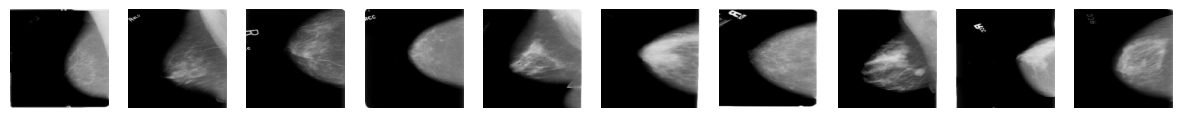

In [11]:
import tensorflow as tf
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

class TFRecordDataset(Dataset):
    def __init__(self, tfrecord_path, img_size=(128, 128), num_samples=None):
        """
        Load images from a TFRecord file.

        - tfrecord_path: Path to the TFRecord file.
        - img_size: Target (H, W) dimensions for images.
        - num_samples: Number of samples to load (if None, load all).
        """
        self.tfrecord_path = tfrecord_path
        self.img_size = img_size
        self.num_samples = num_samples
        self.dataset = self._load_tfrecord()

    def _parse_function(self, example_proto):
        """Parses a single TFRecord example."""
        feature_description = {
            "image": tf.io.FixedLenFeature([], tf.string),
        }
        example = tf.io.parse_single_example(example_proto, feature_description)

        # Decode image and resize
        image = tf.io.decode_jpeg(example["image"])
        image = tf.image.resize(image, self.img_size)
        image = tf.cast(image, tf.float32) / 127.5 - 1  # Normalize to [-1, 1]

        return image

    def _load_tfrecord(self):
        """Loads dataset and limits number of samples if needed."""
        raw_dataset = tf.data.TFRecordDataset(self.tfrecord_path)
        dataset = raw_dataset.map(self._parse_function)

        # Convert dataset to a list and limit to num_samples
        dataset_list = list(dataset.as_numpy_iterator())
        if self.num_samples is not None:
            dataset_list = dataset_list[:self.num_samples]

        return dataset_list

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image = self.dataset[idx]
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)  # Convert (H, W, C) → (C, H, W)
        return image

e = 10
dataset = TFRecordDataset("dataset.tfrecord", img_size=(256, 256), num_samples=e)

# Create DataLoader
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

fig, axes = plt.subplots(1, e, figsize=(15, 5))

for i, img_tensor in enumerate(dataloader):
    if i >= e:
        break

    img_np = img_tensor.squeeze(0).permute(1, 2, 0).numpy()  # Convert (C, H, W) → (H, W, C)
    img_np = (img_np + 1) / 2  # De-normalize back to [0,1]

    axes[i].imshow(img_np)
    axes[i].axis("off")
    print(f"Extracted Image {i+1} Shape: {img_np.shape}")

plt.show()